# ML CUP

In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt

with open("../results/cup.json", "r") as fp:
    results = json.load(fp)

df = {
    k: [res["parameters"][k] for res in results]
    for k in results[0]["parameters"].keys()
}
df["score"] = [res["score"] for res in results]

df = pd.DataFrame(df)
df

,hidden_layer_sizes,activation,learning_rate,lam,alpha,tol,batch_size,shuffle,max_iter,early_stopping,score
0,"[64, 64]",relu,0.03,0.000100,0.9,0.000001,32,True,5000,False,18.791686
1,"[64, 64]",relu,0.03,0.000080,0.9,0.000001,32,True,5000,False,18.828256
2,"[64, 64]",relu,0.05,0.000150,0.9,0.000001,32,True,5000,False,18.879039
3,"[64, 64]",relu,0.05,0.000122,0.9,0.000001,64,True,5000,False,19.053771
4,"[64, 32]",relu,0.03,0.000080,0.7,0.000001,32,True,5000,False,19.082236
...,...,...,...,...,...,...,...,...,...,...,...
4293,"[128, 64, 32]",elu,0.07,0.000100,0.7,0.000010,64,True,3000,False,20.748554
4294,"[128, 64, 32]",elu,0.07,0.000100,0.9,0.000010,32,False,3000,False,21.028345
4295,"[128, 64, 32]",elu,0.07,0.000100,0.9,0.000010,32,True,3000,False,19.580667
4296,"[128, 64, 32]",elu,0.07,0.000100,0.9,0.000010,64,False,3000,False,20.513469


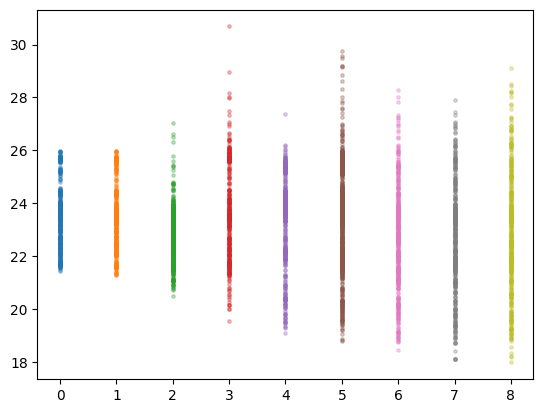

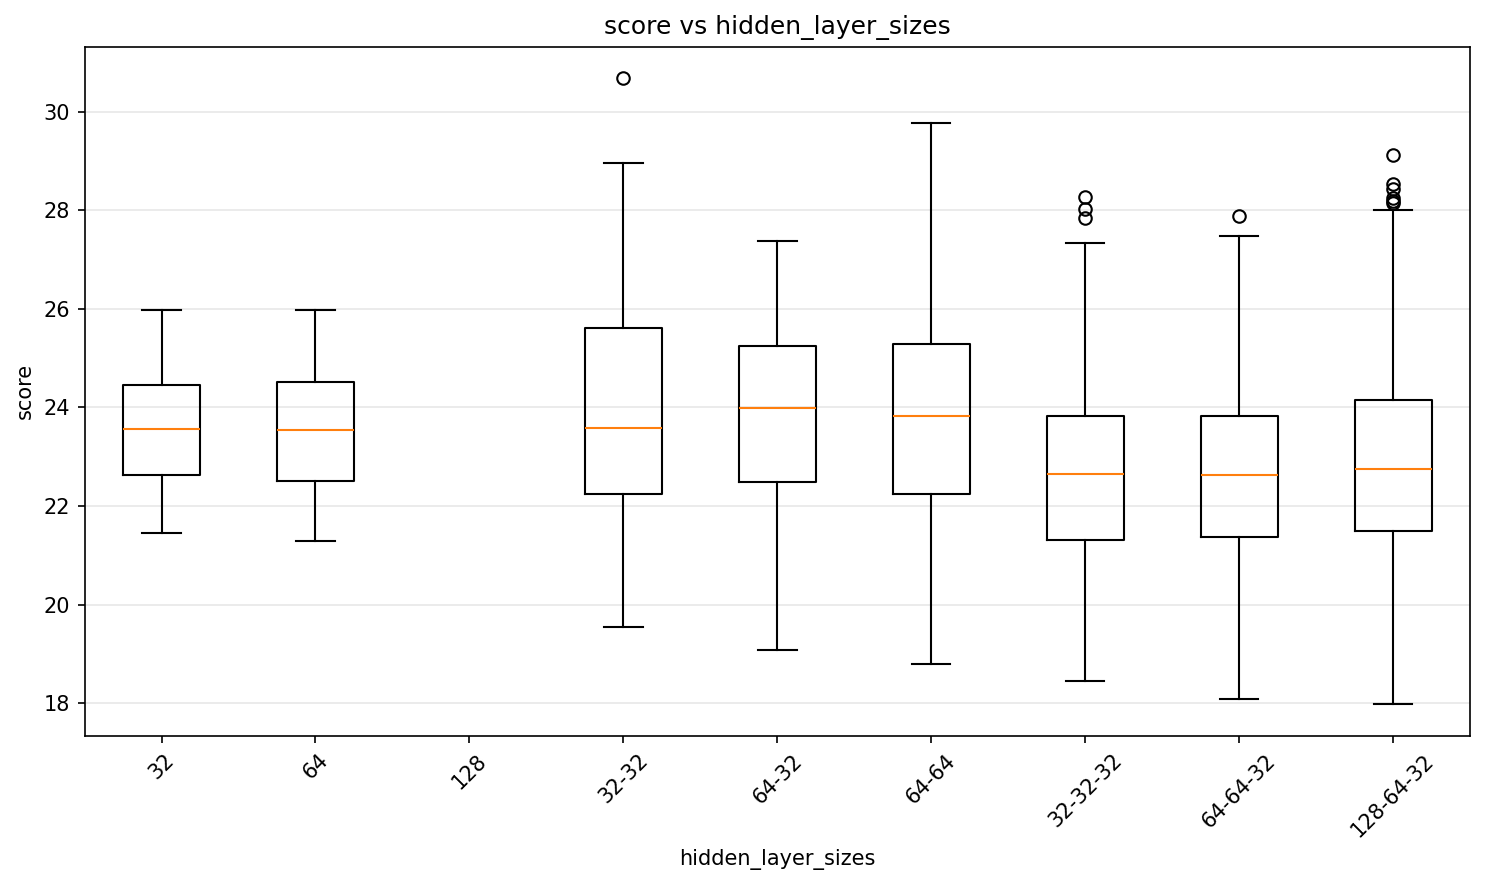

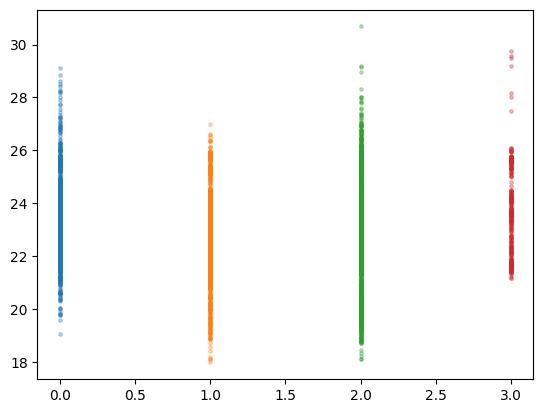

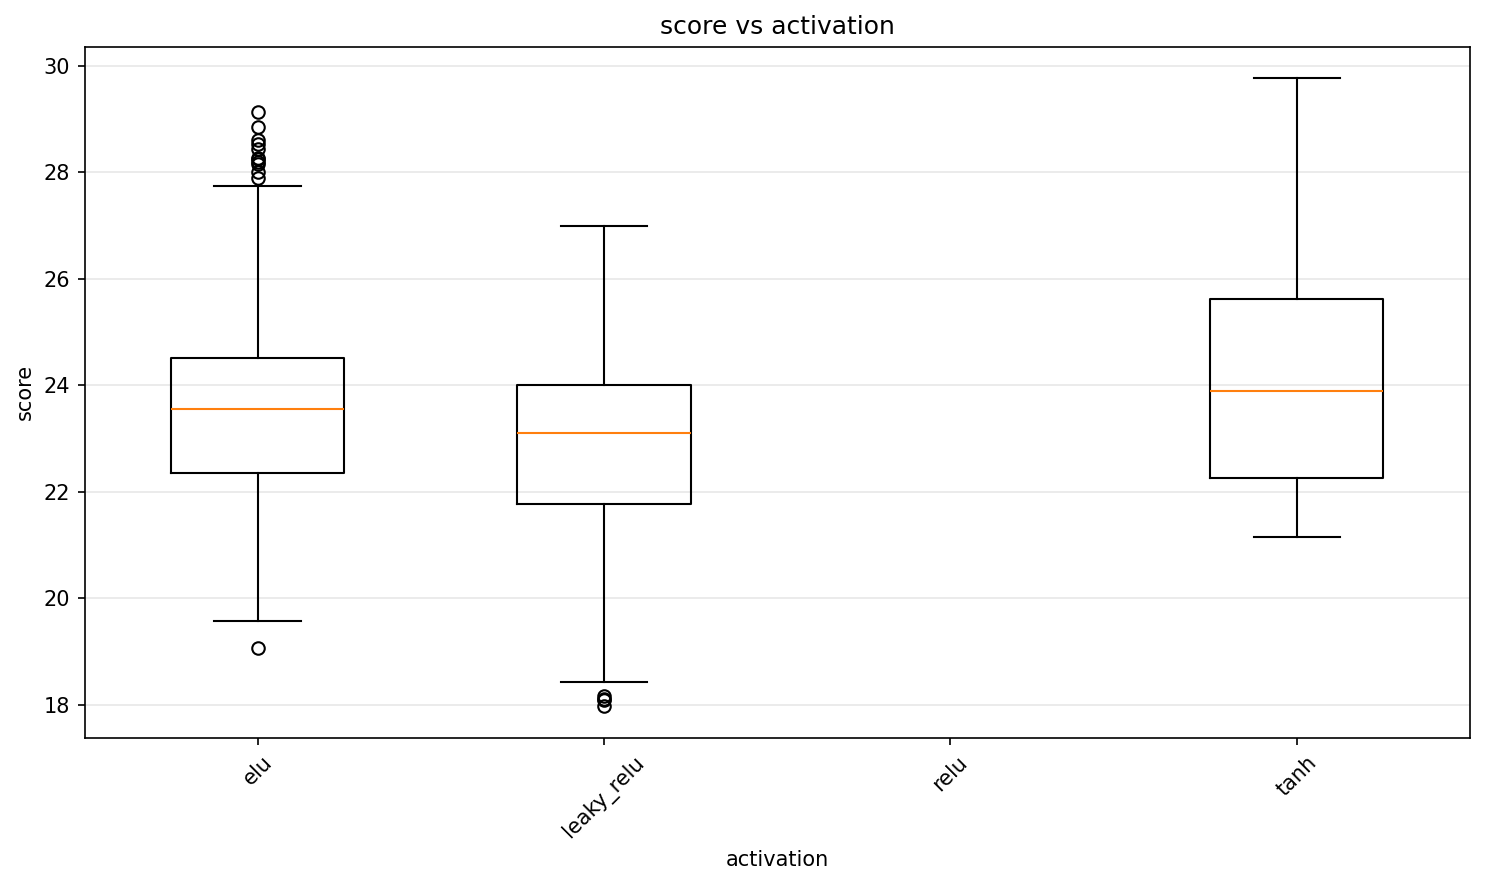

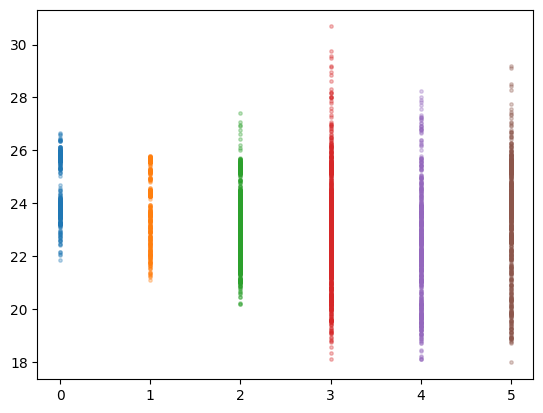

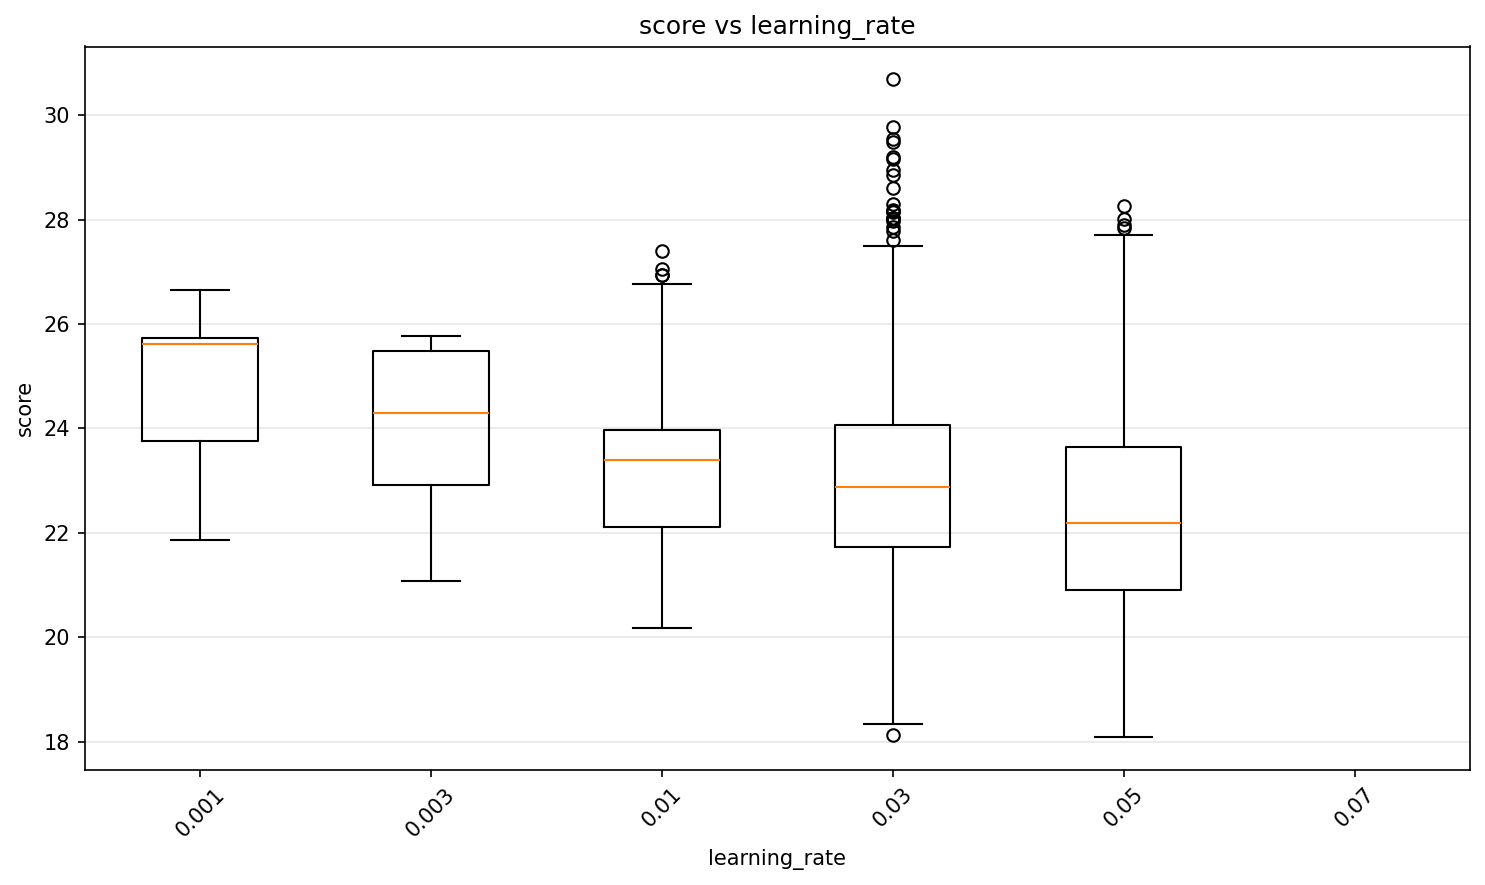

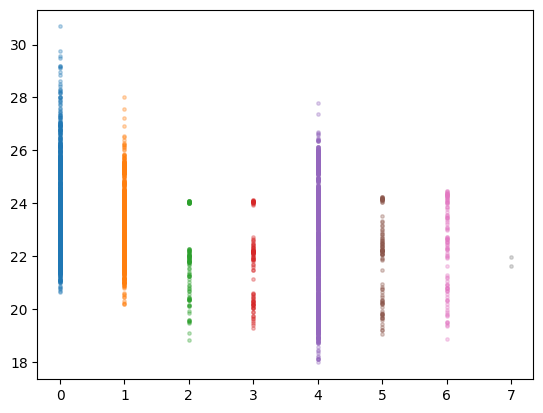

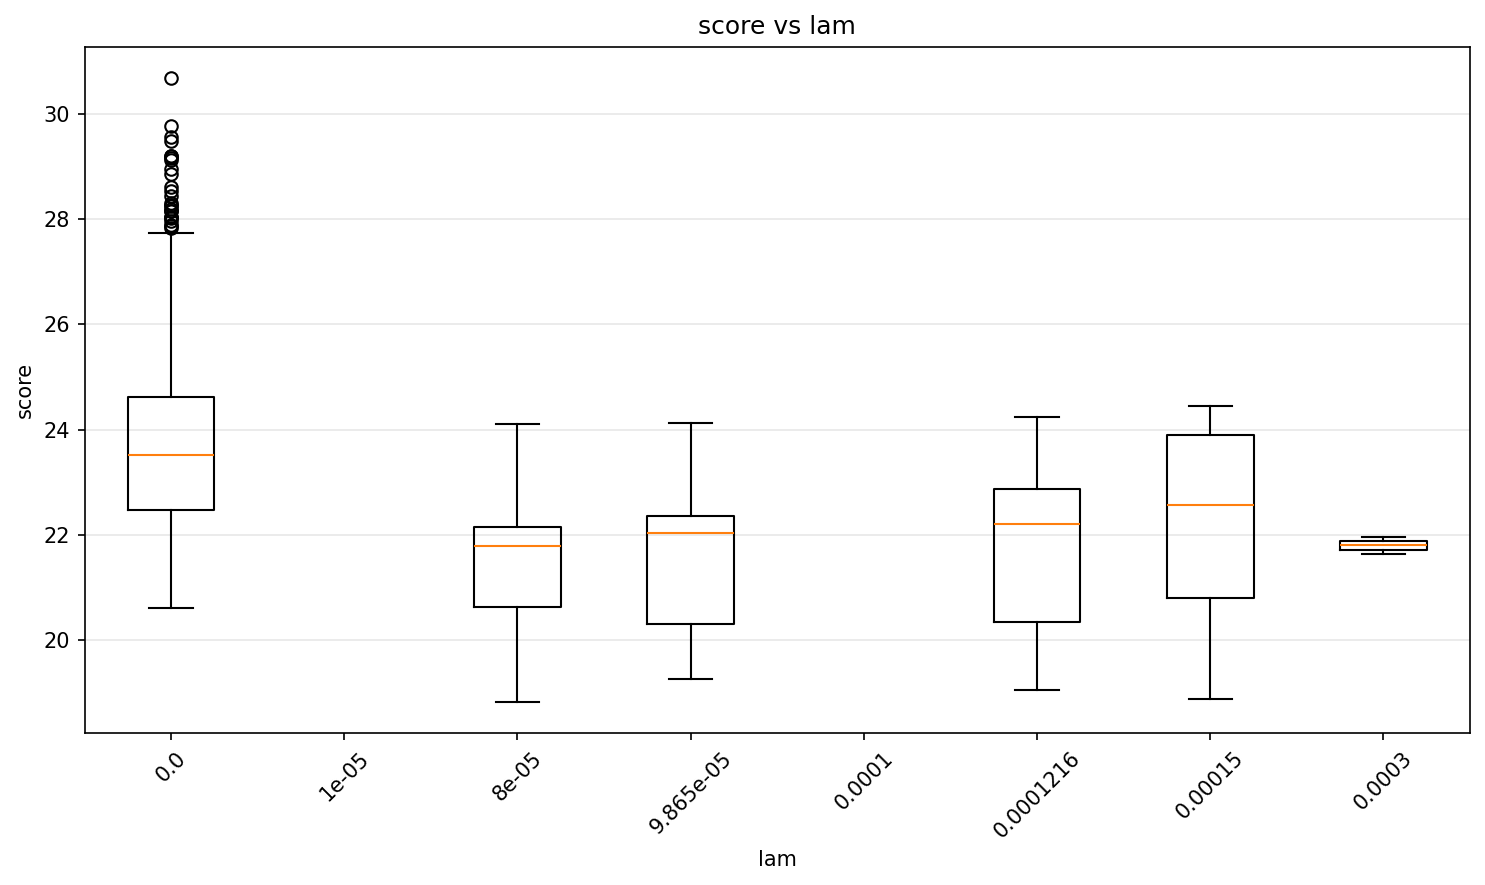

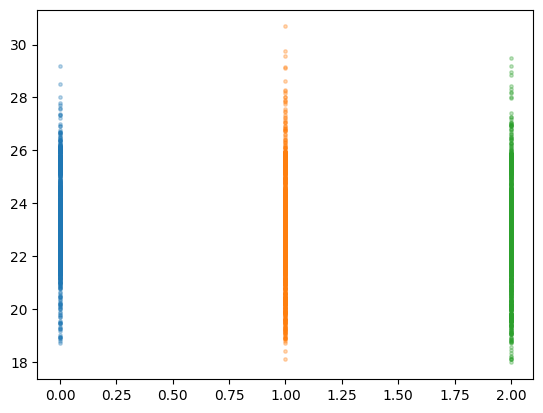

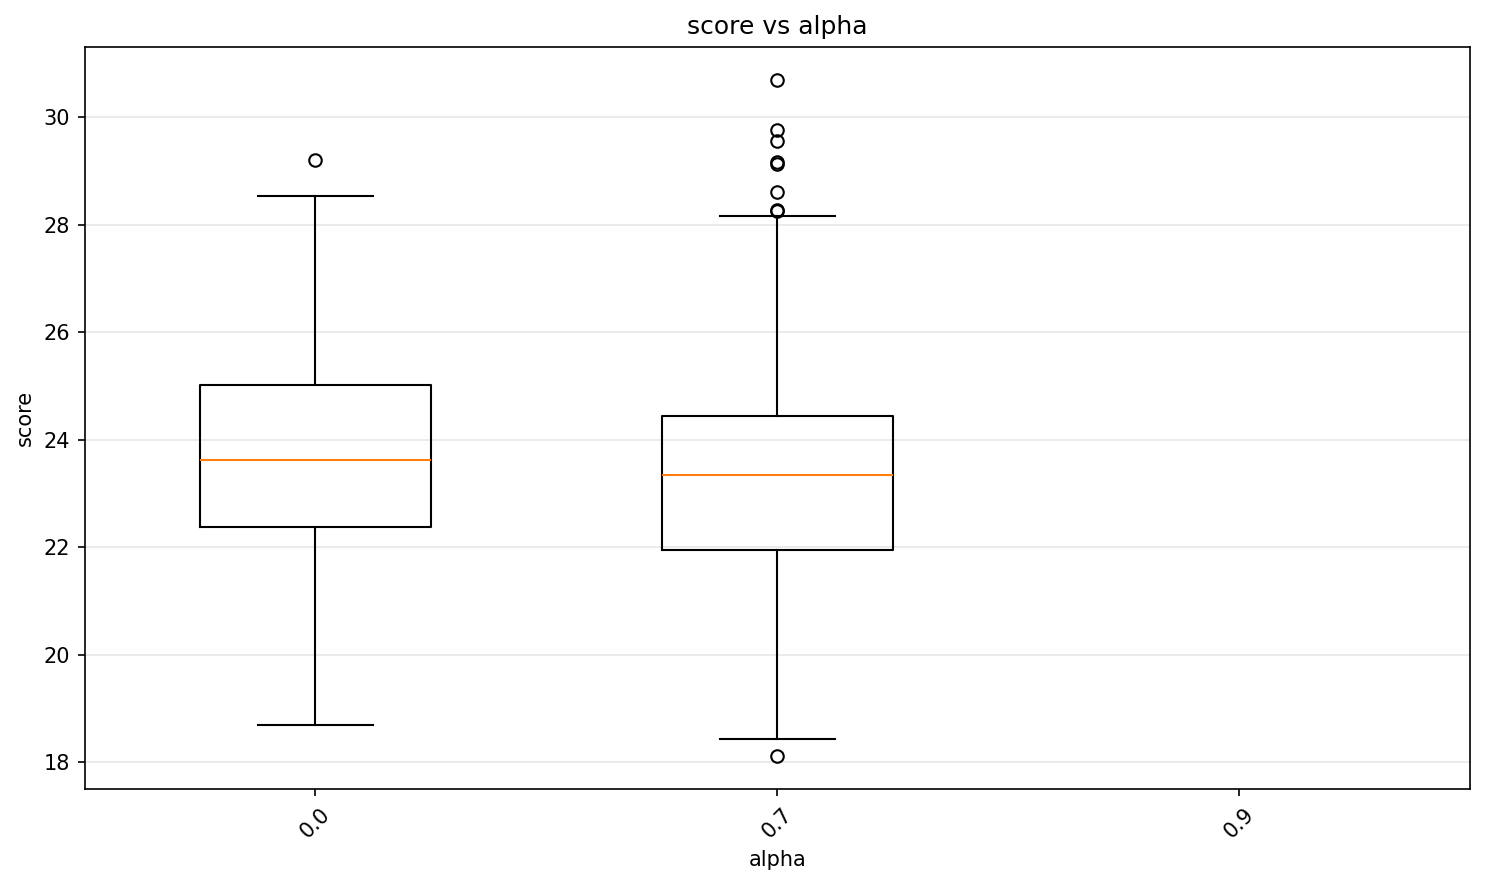

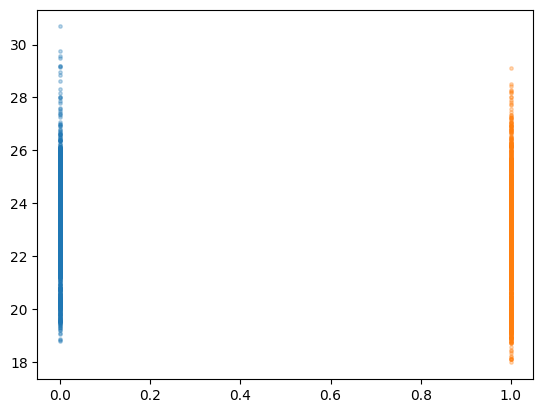

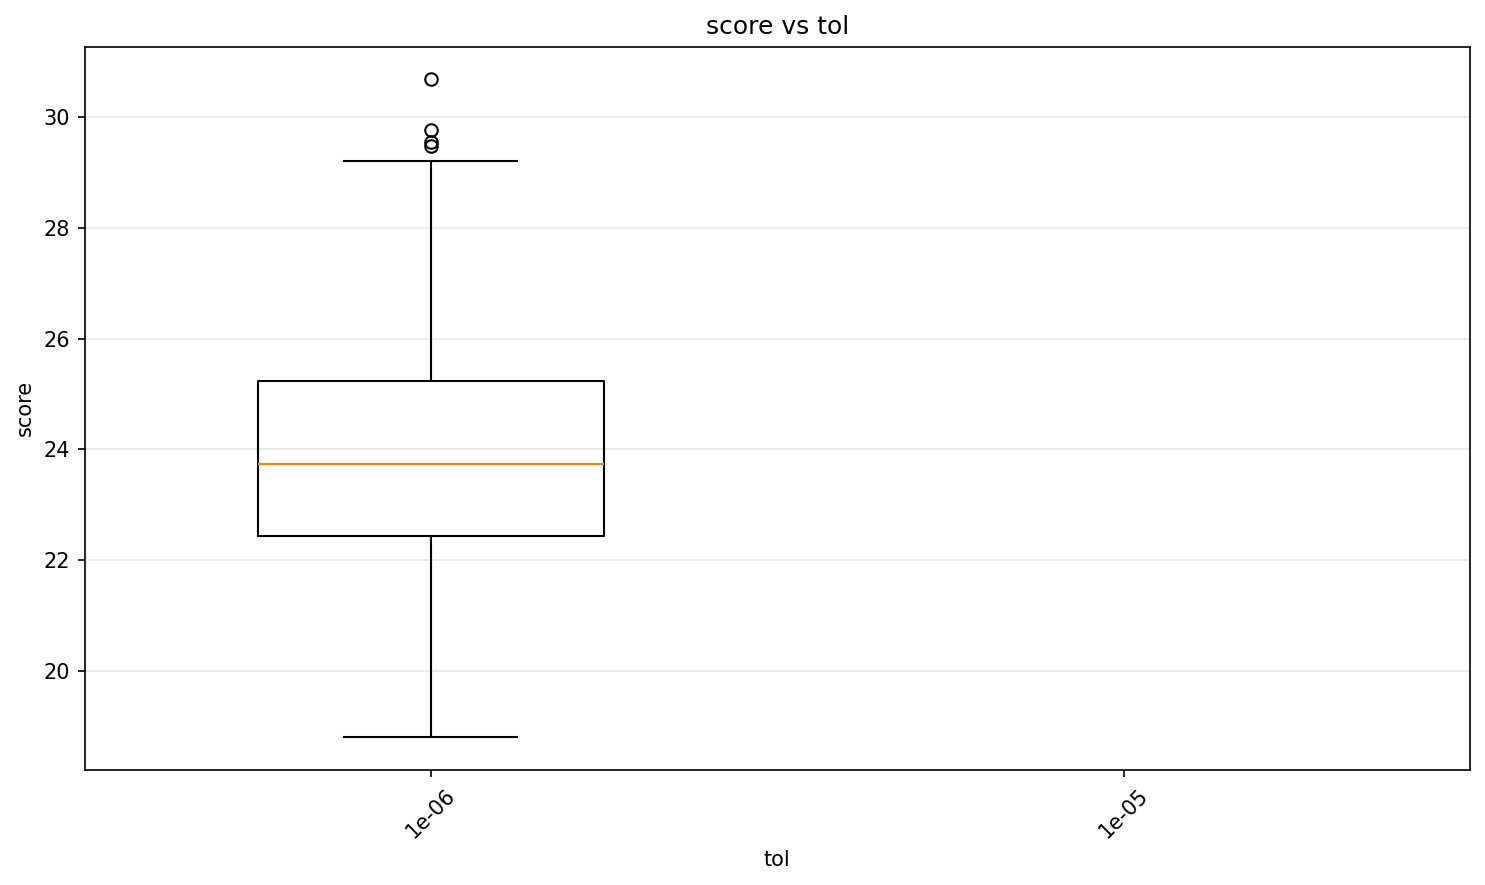

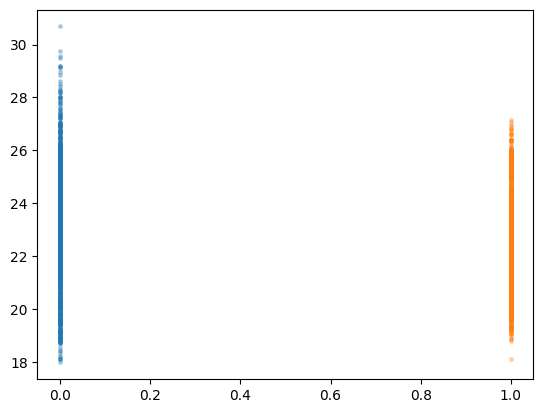

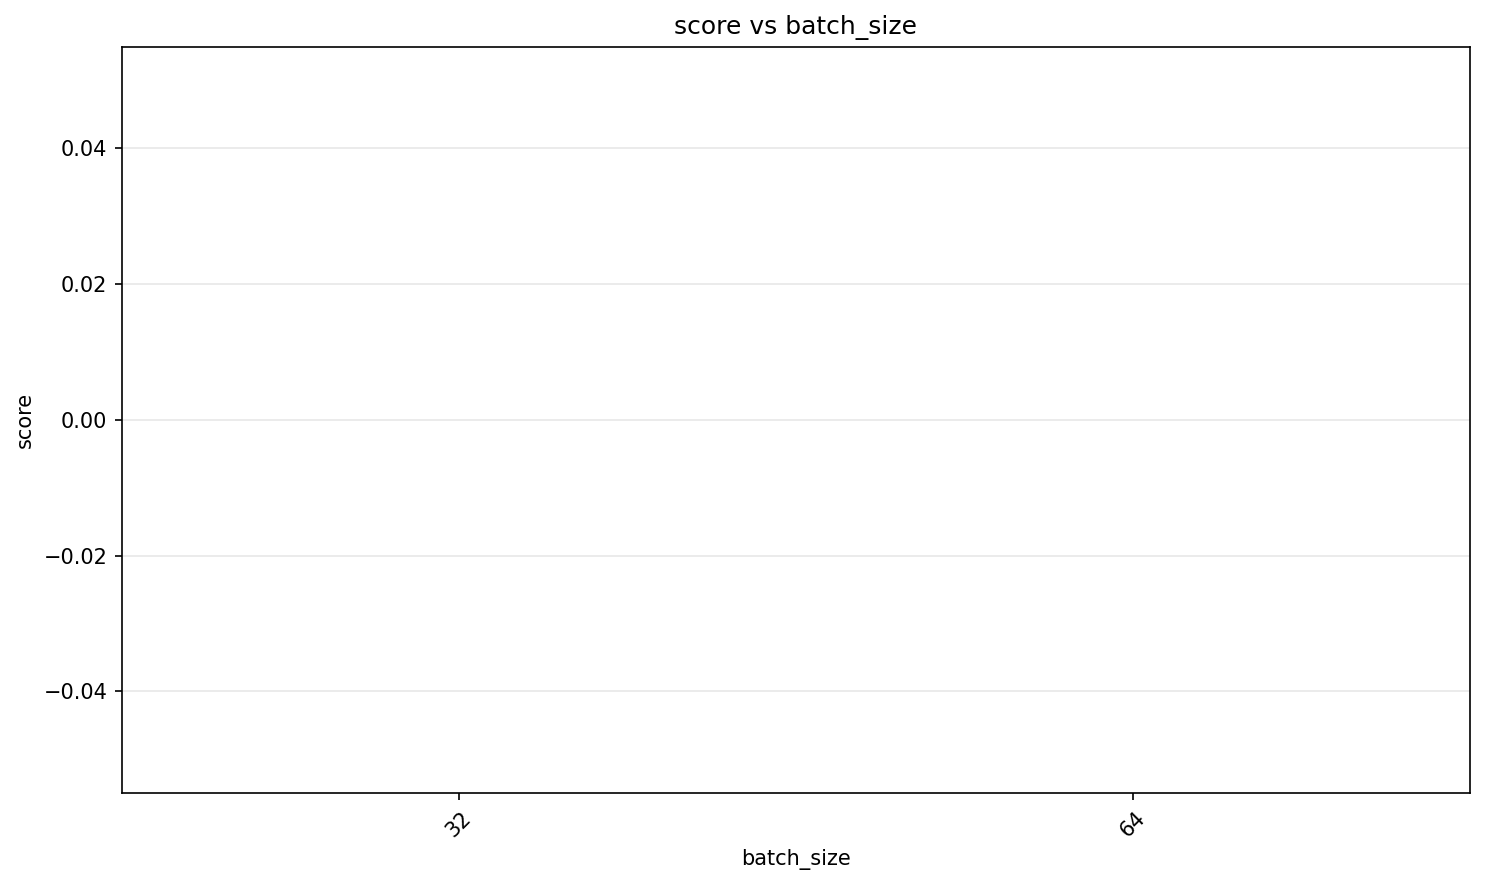

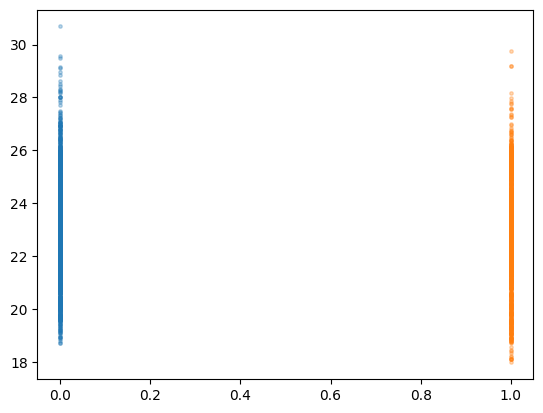

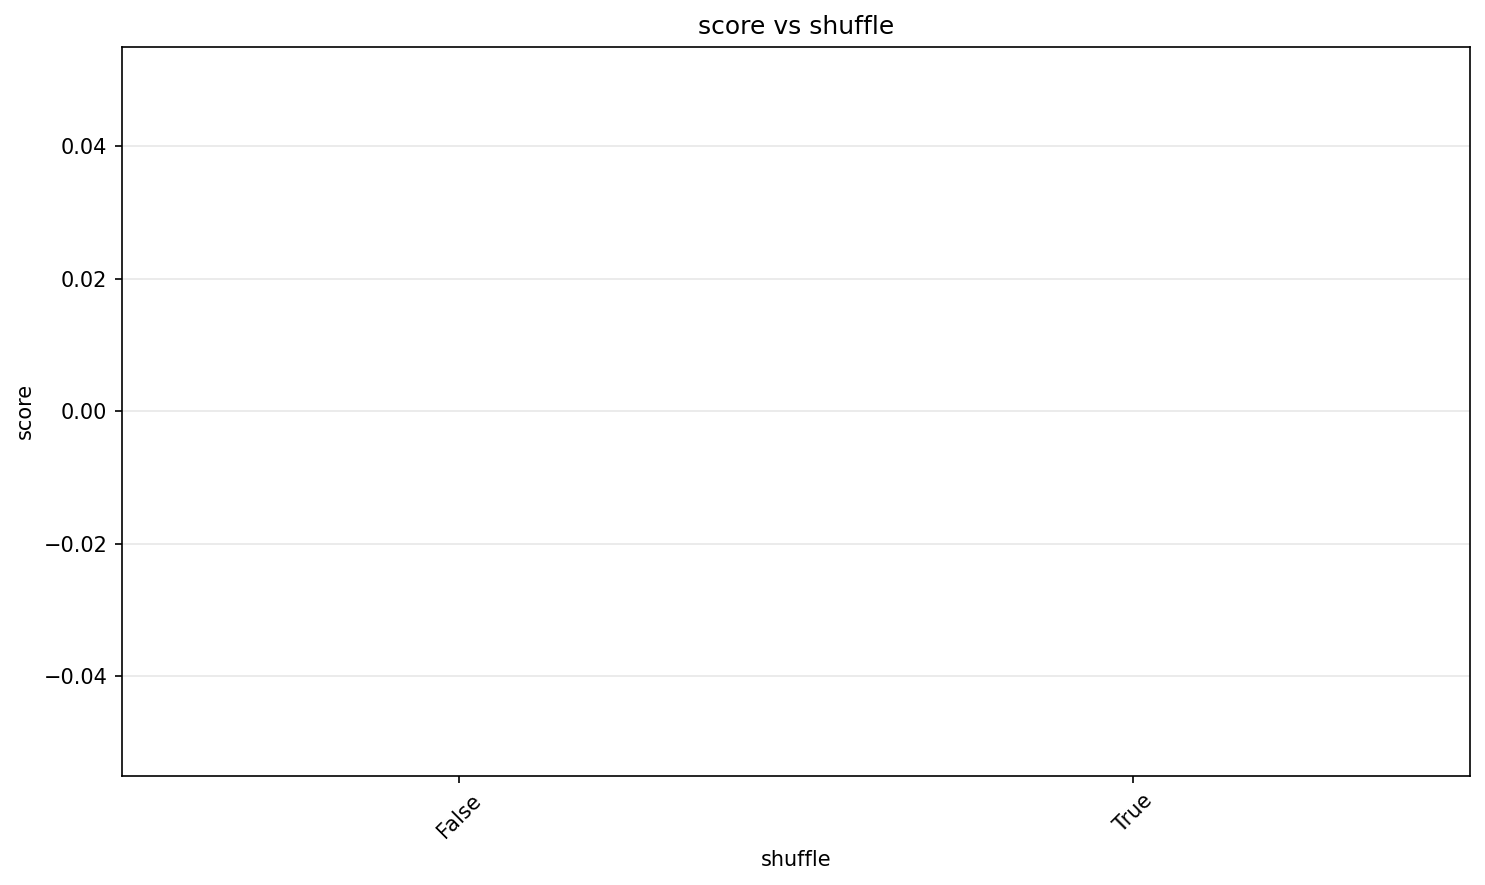

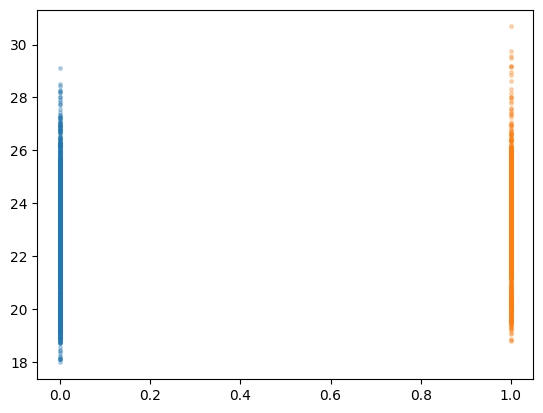

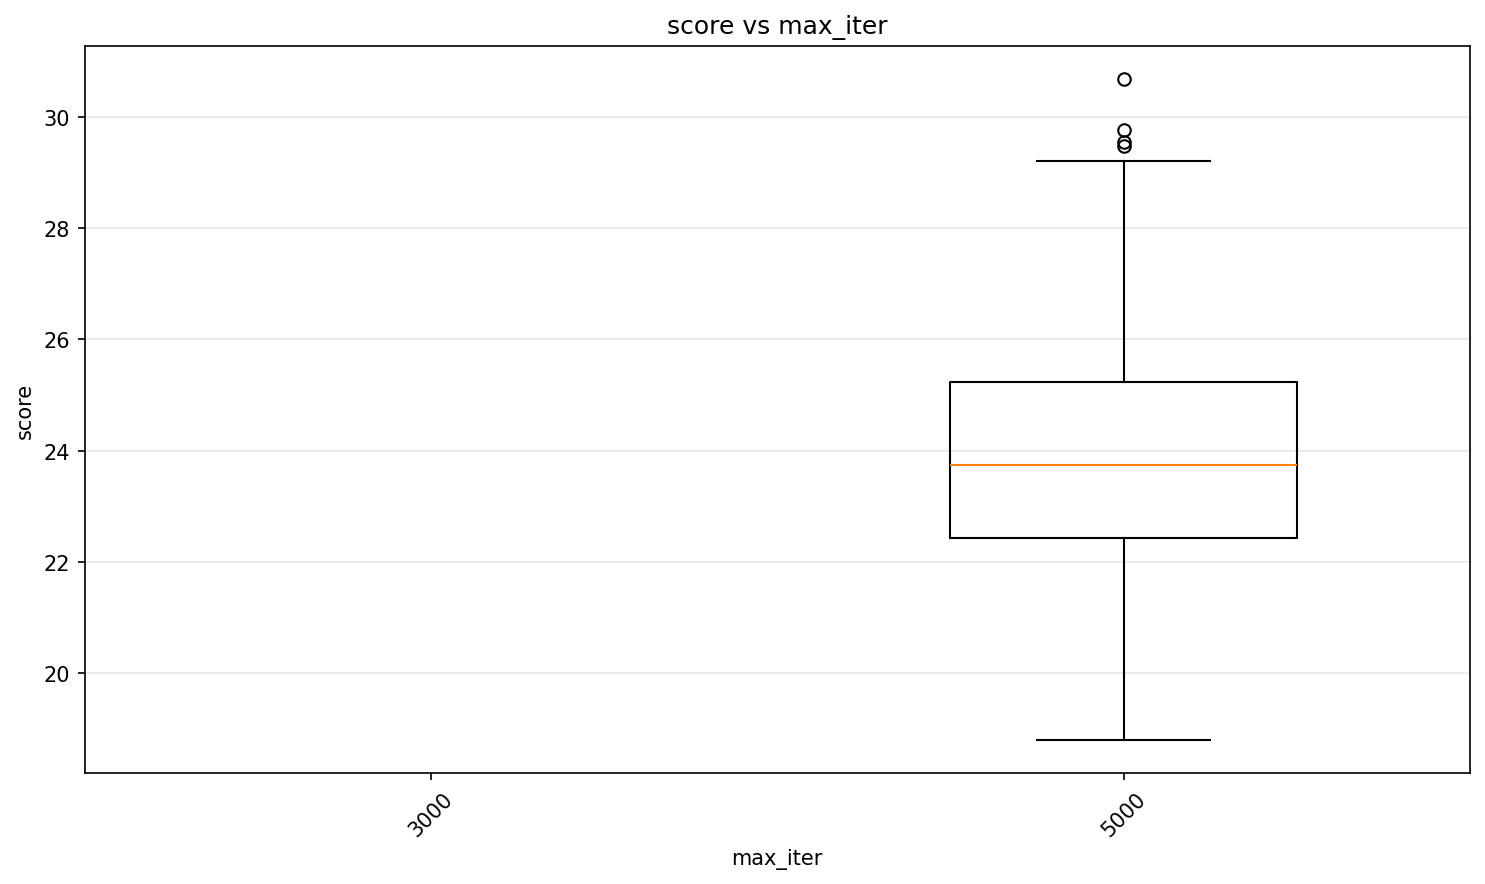

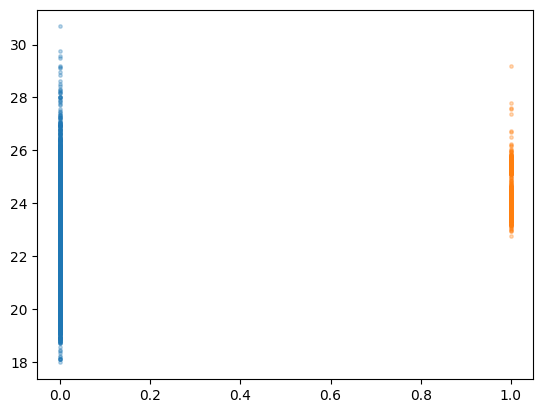

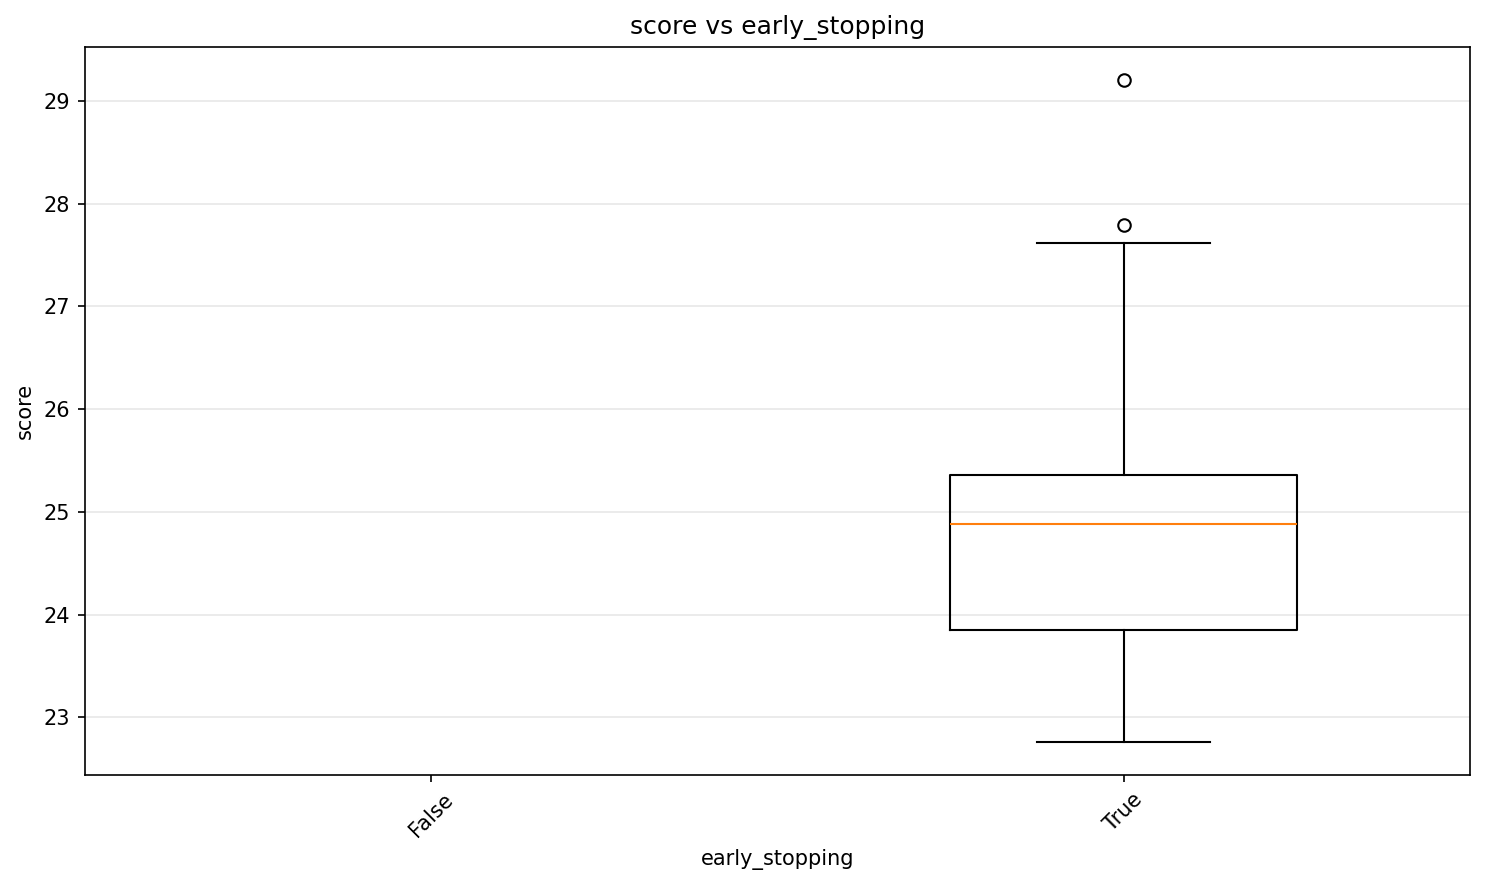

In [15]:
import numpy as np


def param_boxplot(df, param, score_col="score"):
    if param != "hidden_layer_sizes":
        values = sorted(df[param].unique())
        labels = [str(v) for v in values]
        data = [df[df[param] == v][score_col] for v in values]
    else:
        # trasforma tutte le architetture in stringa leggibile
        df = df.copy()
        df["arch_str"] = df[param].apply(lambda x: "-".join(map(str, x)))
        values = sorted(
            df["arch_str"].unique(),
            key=lambda s: (len(s.split("-")), sum(map(int, s.split("-")))),
        )
        data = [df[df["arch_str"] == v][score_col] for v in values]
        labels = values

    for i, d in enumerate(data):
        plt.scatter(
            np.full(len(d), i),
            d,
            alpha=0.3,
            s=6,
            zorder=3,
        )

    plt.figure(figsize=(10, 6), dpi=150)

    plt.boxplot(data, positions=np.arange(1, len(values) + 1), widths=0.5)
    plt.xticks(np.arange(1, len(values) + 1), labels, rotation=45)
    plt.xlabel(param)
    plt.ylabel(score_col)
    plt.title(f"{score_col} vs {param}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


for k in df.columns:
    if k != "score":
        param_boxplot(df, k)